# Price and Volume Feature Families

**Chapter 8: Feature Engineering**
**Section Reference**: 8.2 - Price-Derived Features
**Docker image**: `ml4t`

## Purpose

This notebook demonstrates the **core feature families** derived from a single
asset's price and volume history. These are the workhorse features of most
quantitative strategies — available for every tradeable instrument.

## Learning Objectives

1. Understand the core feature families for price/volume data
2. Implement features with explicit time-safety (sorting, window alignment)
3. Choose appropriate normalization for cross-sectional vs time-series use
4. Compare volatility estimators (close-to-close, Parkinson, Garman-Klass, Yang-Zhang)
5. Build volatility state features (vol ratio, percentile, decile)
6. Avoid common leakage patterns in feature construction

## Feature Families Covered

| Family | Representative Features | Key Use Case |
|--------|------------------------|--------------|
| **Returns & Horizons** | Simple, log, skip-1, cumulative | Base signals |
| **Trend & Reversal** | MA distance, regression slope, dist-to-MA | Momentum/reversion |
| **Volatility** | CC, Parkinson, GK, YZ, vol-of-vol | Risk scaling |
| **Volatility State** | Vol ratio, percentile, decile | Regime conditioning |
| **Volume & Liquidity** | Dollar volume, relative volume, VWAP | Capacity signals |
| **Risk** | VaR, CVaR, tail ratio | Position sizing |
| **Cross-Sectional** | Ranks, z-scores | Universe normalization |

## Data Policy

All examples use **real ETF data** (no synthetic data).

In [1]:
"""Price and Volume Feature Families — core feature families derived from a single asset's price and volume history."""

from __future__ import annotations

import warnings
from datetime import datetime

import numpy as np
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from utils.paths import get_chapter_dir
from utils.style import COLORS  # importing utils.style sets the ml4t Plotly template as default

warnings.filterwarnings("ignore")

In [2]:
SEED = 42
START_DATE = "2015-01-01"

## 0. Feature Discovery with ml4t-engineer

Before building features manually, let's see what the `ml4t-engineer` library
offers. The registry provides 120 pre-built, validated features that the
case study notebooks use throughout Chapters 8-12.

For a full tour of the library ecosystem (data loaders, feature computation,
evaluation tools), see `10_ml4t_library_ecosystem` in Chapter 7.

In [3]:
from ml4t.engineer import compute_features
from ml4t.engineer.core.registry import get_registry

registry = get_registry()
all_features = registry.list_all()

# Features by category
categories = {}
for name in all_features:
    metadata = registry.get(name)
    categories.setdefault(metadata.category, []).append(name)

print(f"Total features available: {len(all_features)}\n")
print("Features by category:")
for cat, feats in sorted(categories.items()):
    examples = ", ".join(feats[:4])
    suffix = ", ..." if len(feats) > 4 else ""
    print(f"  {cat:20s}: {len(feats):3d}  ({examples}{suffix})")

Total features available: 120

Features by category:
  math                :   3  (maximum, minimum, summation)
  microstructure      :  15  (amihud_illiquidity, bid_ask_imbalance, book_depth_ratio, effective_tick_rule, ...)
  ml                  :  14  (create_lag_features, cyclical_encode, directional_targets, ffdiff, ...)
  momentum            :  31  (adx, adxr, apo, aroon, ...)
  price_transform     :   5  (avgprice, medprice, midprice, typprice, ...)
  regime              :   4  (choppiness_index, fractal_efficiency, hurst_exponent, trend_intensity_index)
  risk                :   6  (downside_deviation, higher_moments, maximum_drawdown, risk_adjusted_returns, ...)
  statistics          :  14  (avgdev, coefficient_of_variation, linearreg, linearreg_angle, ...)
  trend               :  10  (dema, donchian_channels, ema, kama, ...)
  volatility          :  15  (atr, bollinger_bands, conditional_volatility_ratio, ewma_volatility, ...)
  volume              :   3  (ad, adosc, obv)


### Feature metadata

Each registry entry carries self-documenting metadata: formula, parameters,
input type, and description. This makes features discoverable without reading
source code.

In [4]:
rsi_meta = registry.get("rsi")
print(f"Feature:     {rsi_meta.name}")
print(f"Category:    {rsi_meta.category}")
print(f"Formula:     {rsi_meta.formula}")
print(f"Parameters:  {rsi_meta.parameters}")
print(f"Input type:  {rsi_meta.input_type}")

Feature:     rsi
Category:    momentum
Formula:     RSI = 100 - (100 / (1 + RS)) where RS = Average Gain / Average Loss
Parameters:  {'period': 14}
Input type:  close


### Quick computation

`compute_features()` accepts a list of feature names (default parameters)
or dicts (custom parameters). We'll use it throughout the case study
notebooks; the sections below show the manual implementations for teaching.

In [5]:
from data import load_etfs

spy_quick = load_etfs().filter(pl.col("symbol") == "SPY").sort("timestamp").tail(500)

result = compute_features(spy_quick, ["rsi", "atr", "sma"])
new_cols = [c for c in result.columns if c not in spy_quick.columns]
print(f"Computed {len(new_cols)} feature columns: {new_cols}")
result.select(["timestamp", "close"] + new_cols).tail(5)

Computed 3 feature columns: ['atr', 'rsi', 'sma']


timestamp,close,atr,rsi,sma
date,f64,f64,f64,f64
2025-12-24,688.499695,6.774438,61.844868,679.29946
2025-12-26,688.429871,6.460795,61.758785,679.929361
2025-12-29,685.976562,6.301341,58.668815,680.252148
2025-12-30,685.138916,5.992287,57.608979,680.688171
2025-12-31,680.062744,5.966736,51.533487,680.807739


The notebooks that follow build these features manually to explain the
economics and implementation details, then use the registry for production
pipelines.

## 1. Data Loading and Sorting

**Critical**: All rolling/window operations require chronological ordering.
We establish sorting once at data load, not implicitly per operation.

In [6]:
# Load and sort by symbol, then timestamp (CRITICAL for .over() operations)
etfs = load_etfs().sort(["symbol", "timestamp"])

# Filter date range
etfs = etfs.filter(pl.col("timestamp") >= datetime.strptime(START_DATE, "%Y-%m-%d"))

# For single-asset demos: SPY
spy = etfs.filter(pl.col("symbol") == "SPY").sort("timestamp")

# For cross-sectional demos: subset of liquid ETFs
cs_symbols = ["SPY", "QQQ", "IWM", "TLT", "GLD", "XLF", "XLE", "XLK"]
cs_etfs = etfs.filter(pl.col("symbol").is_in(cs_symbols)).sort(["symbol", "timestamp"])

print(f"SPY: {len(spy):,} rows")
print(f"Cross-sectional universe: {len(cs_etfs):,} rows, {cs_etfs['symbol'].n_unique()} symbols")
print(f"Date range: {spy['timestamp'].min()} to {spy['timestamp'].max()}")

SPY: 2,766 rows
Cross-sectional universe: 22,128 rows, 8 symbols
Date range: 2015-01-02 to 2025-12-31


## 2. Returns and Horizons

Returns are the foundation of all momentum features. Key variants:

| Variant | Formula | Use Case |
|---------|---------|----------|
| Simple return | $(P_t - P_{t-h}) / P_{t-h}$ | Standard momentum |
| Log return | $\ln(P_t / P_{t-h})$ | Additive across time |
| Skip-1 momentum | $r_{t-1:t-h}$ | Avoid microstructure noise |
| Cumulative | $\sum_{i=0}^{h} r_{t-i}$ | Multi-period signals |

### 2.1 Manual Implementation (Teaching)

Understanding the mechanics of return computation.

In [7]:
def compute_returns_manual(df: pl.DataFrame, horizons: list[int]) -> pl.DataFrame:
    """
    Compute returns for multiple horizons using pure Polars.

    Note: This is for teaching. Use ml4t-engineer in production.
    """
    return_exprs = []

    for h in horizons:
        # Simple returns
        return_exprs.append(pl.col("close").pct_change(h).alias(f"ret_{h}d"))
        # Log returns
        return_exprs.append(
            (pl.col("close").log() - pl.col("close").log().shift(h)).alias(f"logret_{h}d")
        )

    return df.with_columns(return_exprs)


# Single with_columns for efficiency
returns_df = compute_returns_manual(spy, horizons=[1, 5, 21])

print("Return features computed:")
returns_df.select(["timestamp", "close", "ret_1d", "ret_5d", "ret_21d"]).tail(10)

Return features computed:


timestamp,close,ret_1d,ret_5d,ret_21d
date,f64,f64,f64,f64
2025-12-17,667.598694,-0.011004,-0.023518,0.008608
2025-12-18,672.639954,0.007551,-0.018428,0.02483
2025-12-19,678.736389,0.009063,0.001234,0.030139
2025-12-22,682.964844,0.00623,0.008996,0.052601
2025-12-23,686.086304,0.00457,0.016384,0.046982
2025-12-24,688.499695,0.003518,0.031308,0.035425
2025-12-26,688.429871,-0.000101,0.023475,0.025673
2025-12-29,685.976562,-0.003564,0.010667,0.015011
2025-12-30,685.138916,-0.001221,0.003183,0.008268


### 2.2 Skip-1 Momentum

Skip the most recent day to avoid microstructure reversals (bid-ask bounce).

$$\text{Skip-1 Momentum}_{21d} = \frac{P_{t-1}}{P_{t-21}} - 1$$

In [8]:
# Skip-1 momentum: shift(1) before computing the horizon return
skip1_df = spy.with_columns(
    [
        # Standard 21-day momentum
        pl.col("close").pct_change(21).alias("mom_21d"),
        # Skip-1: use yesterday's close as numerator
        ((pl.col("close").shift(1) / pl.col("close").shift(21)) - 1).alias("mom_21d_skip1"),
    ]
)

# Show correlation - should be high but not identical
correlation = skip1_df.drop_nulls().select(
    [pl.corr("mom_21d", "mom_21d_skip1").alias("correlation")]
)
print(f"Correlation between standard and skip-1 momentum: {correlation[0, 0]:.4f}")

Correlation between standard and skip-1 momentum: 0.9707


**Interpretation**: A correlation of ~0.97 confirms the two series carry
very similar information at the 21-day horizon. The skip-1 variant removes
the last day's microstructure noise (bid-ask bounce), so it is preferred for
daily-rebalanced strategies where the most recent close is noisiest.

### 2.3 Session-Based Returns

Decomposing returns into overnight (gap) and intraday components:

- **Overnight return**: $\frac{Open_t}{Close_{t-1}} - 1$
- **Intraday return**: $\frac{Close_t}{Open_t} - 1$

In [9]:
session_df = spy.with_columns(
    [
        # Overnight (gap)
        ((pl.col("open") / pl.col("close").shift(1)) - 1).alias("overnight_ret"),
        # Intraday
        ((pl.col("close") / pl.col("open")) - 1).alias("intraday_ret"),
        # Total for reference
        pl.col("close").pct_change().alias("total_ret"),
    ]
)

# Verify decomposition: (1 + overnight) * (1 + intraday) ≈ (1 + total)
session_df = session_df.with_columns(
    ((1 + pl.col("overnight_ret")) * (1 + pl.col("intraday_ret")) - 1).alias("reconstructed")
)

print("Session return decomposition:")
session_df.select(
    ["timestamp", "overnight_ret", "intraday_ret", "total_ret", "reconstructed"]
).tail(10)

Session return decomposition:


timestamp,overnight_ret,intraday_ret,total_ret,reconstructed
date,f64,f64,f64,f64
2025-12-17,0.001502,-0.012487,-0.011004,-0.011004
2025-12-18,0.009234,-0.001668,0.007551,0.007551
2025-12-19,0.003133,0.005912,0.009063,0.009063
2025-12-22,0.004922,0.001301,0.00623,0.00623
2025-12-23,-0.001329,0.005907,0.00457,0.00457
2025-12-24,-0.000015,0.003532,0.003518,0.003518
2025-12-26,0.000377,-0.000478,-0.000101,-0.000101
2025-12-29,-0.004013,0.000451,-0.003564,-0.003564
2025-12-30,-0.000581,-0.00064,-0.001221,-0.001221


## 3. Trend and Reversal Features

These features capture where price is relative to historical patterns.

| Feature | Signal Type | Interpretation |
|---------|-------------|----------------|
| MA Distance | Trend | >0 bullish, <0 bearish |
| Regression Slope | Trend strength | Steeper = stronger trend |
| Short-term Reversal | Mean reversion | Oversold/overbought |

### 3.1 MA Distance (Volatility-Scaled)

Raw MA distance varies with price level. Scaling by volatility creates
a standardized signal comparable across assets and time.

$$\text{MA Distance} = \frac{P_t - SMA_{21}}{ATR_{21}}$$

In [10]:
from ml4t.engineer.features.volatility import atr

# MA distance scaled by ATR
ma_df = spy.with_columns(
    [
        pl.col("close").rolling_mean(21).alias("sma_21"),
        atr("high", "low", "close", period=21).alias("atr_21"),
    ]
).with_columns(
    [
        # Raw distance (not comparable across assets)
        (pl.col("close") - pl.col("sma_21")).alias("ma_dist_raw"),
        # Vol-scaled (standardized)
        ((pl.col("close") - pl.col("sma_21")) / pl.col("atr_21")).alias("ma_dist_scaled"),
    ]
)

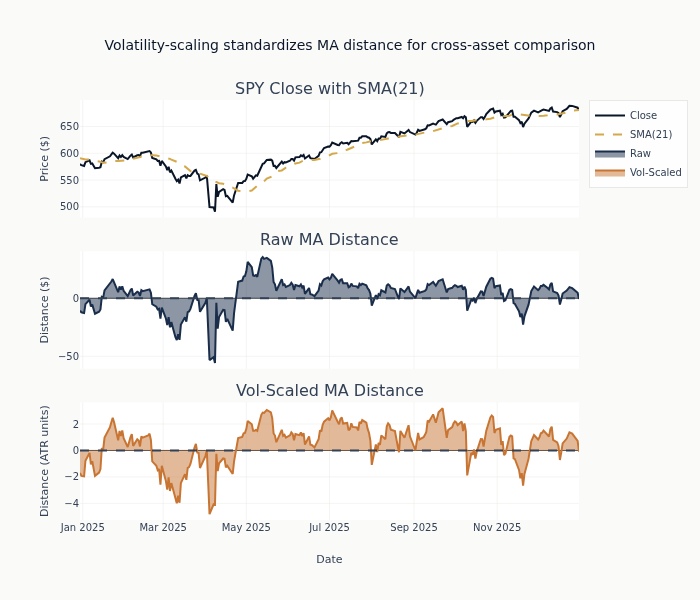

In [11]:
# Visualize MA distance
fig = make_subplots(
    rows=3,
    cols=1,
    shared_xaxes=True,
    subplot_titles=["SPY Close with SMA(21)", "Raw MA Distance", "Vol-Scaled MA Distance"],
    vertical_spacing=0.08,
)

n = 252  # Last year
fig.add_trace(
    go.Scatter(x=ma_df["timestamp"].to_list()[-n:], y=ma_df["close"].to_list()[-n:], name="Close"),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=ma_df["timestamp"].to_list()[-n:],
        y=ma_df["sma_21"].to_list()[-n:],
        name="SMA(21)",
        line=dict(dash="dash"),
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=ma_df["timestamp"].to_list()[-n:],
        y=ma_df["ma_dist_raw"].to_list()[-n:],
        name="Raw",
        fill="tozeroy",
    ),
    row=2,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=ma_df["timestamp"].to_list()[-n:],
        y=ma_df["ma_dist_scaled"].to_list()[-n:],
        name="Vol-Scaled",
        fill="tozeroy",
    ),
    row=3,
    col=1,
)
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], row=2, col=1)
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], row=3, col=1)

fig.update_yaxes(title_text="Price ($)", row=1, col=1)
fig.update_yaxes(title_text="Distance ($)", row=2, col=1)
fig.update_yaxes(title_text="Distance (ATR units)", row=3, col=1)
fig.update_xaxes(title_text="Date", row=3, col=1)
fig.update_layout(
    height=600, title="Volatility-scaling standardizes MA distance for cross-asset comparison"
)
fig.show()

### 3.2 Rolling Regression Slope

OLS slope over a rolling window measures trend strength more robustly than
endpoint-to-endpoint returns: it uses all intermediate prices and is less
sensitive to start/end outliers.

For evenly spaced data with $x = [0, 1, \ldots, n-1]$:

$$\hat\beta = \frac{\text{Cov}(x, P)}{\text{Var}(x)}$$

We normalize by mean price to get a percentage slope comparable across assets.

In [12]:
def rolling_regression_slope(
    df: pl.DataFrame,
    price_col: str = "close",
    period: int = 21,
) -> pl.DataFrame:
    """Rolling OLS slope, normalized by mean price."""
    return df.with_columns(
        pl.col(price_col)
        .rolling_map(
            lambda s: np.polyfit(np.arange(len(s)), s.to_numpy(), 1)[0] / s.mean() * len(s),
            window_size=period,
            min_periods=period,
        )
        .alias(f"slope_{period}d")
    )


slope_df = rolling_regression_slope(spy, period=21)
print("Rolling regression slope (normalized %-change over 21d):")
slope_df.select(["timestamp", "close", "slope_21d"]).tail(10)

Rolling regression slope (normalized %-change over 21d):


timestamp,close,slope_21d
date,f64,f64
2025-12-17,667.598694,0.034546
2025-12-18,672.639954,0.026962
2025-12-19,678.736389,0.022323
2025-12-22,682.964844,0.014129
2025-12-23,686.086304,0.008719
2025-12-24,688.499695,0.007328
2025-12-26,688.429871,0.007732
2025-12-29,685.976562,0.008508
2025-12-30,685.138916,0.010171


### 3.3 Short-Term Reversal

Recent underperformers tend to outperform in the short term (1-5 days).
This is the complement to momentum.

$$\text{Reversal} = -r_{1d}$$

In [13]:
reversal_df = spy.with_columns(
    [
        pl.col("close").pct_change(1).alias("ret_1d"),
        (-pl.col("close").pct_change(1)).alias("reversal_1d"),
        # Z-scored reversal for comparability
        (
            (-pl.col("close").pct_change(1) - (-pl.col("close").pct_change(1)).rolling_mean(63))
            / (-pl.col("close").pct_change(1)).rolling_std(63)
        ).alias("reversal_zscore"),
    ]
)

print("Short-term reversal features:")
reversal_df.select(["timestamp", "close", "ret_1d", "reversal_1d"]).tail(10)

Short-term reversal features:


timestamp,close,ret_1d,reversal_1d
date,f64,f64,f64
2025-12-17,667.598694,-0.011004,0.011004
2025-12-18,672.639954,0.007551,-0.007551
2025-12-19,678.736389,0.009063,-0.009063
2025-12-22,682.964844,0.00623,-0.00623
2025-12-23,686.086304,0.00457,-0.00457
2025-12-24,688.499695,0.003518,-0.003518
2025-12-26,688.429871,-0.000101,0.000101
2025-12-29,685.976562,-0.003564,0.003564
2025-12-30,685.138916,-0.001221,0.001221


### 3.4 Directional Persistence: Distance to MA in ATR Units

This extends the vol-scaled MA distance from §3.1 with different parameters
and interpretation. Where §3.1 uses SMA(21)/ATR(21) to measure *current*
deviation, here MA(50)/ATR(14) captures *directional persistence* — how
far price has trended away from a slower anchor.

$$\text{dist\_to\_ma\_atr} = \frac{P_t - MA_{50}}{ATR_{14}}$$

ATR is used here for normalization (price-denominated), not as a volatility
estimator — see §4 for the distinction.

In [14]:
dist_ma_df = spy.with_columns(
    [
        pl.col("close").rolling_mean(50).alias("ma_50"),
        atr("high", "low", "close", period=14).alias("atr_14"),
    ]
).with_columns(
    ((pl.col("close") - pl.col("ma_50")) / pl.col("atr_14").clip(1e-10, None)).alias(
        "dist_to_ma_atr"
    ),
)

print("Distance to MA in ATR units:")
dist_ma_df.select(["timestamp", "close", "ma_50", "atr_14", "dist_to_ma_atr"]).tail(10)

Distance to MA in ATR units:


timestamp,close,ma_50,atr_14,dist_to_ma_atr
date,f64,f64,f64,f64
2025-12-17,667.598694,671.012665,7.400249,-0.461332
2025-12-18,672.639954,671.079484,7.535024,0.207096
2025-12-19,678.736389,671.30701,7.467885,0.994844
2025-12-22,682.964844,671.979852,7.274249,1.51012
2025-12-23,686.086304,672.515858,7.063104,1.921315
2025-12-24,688.499695,673.11624,6.774438,2.270809
2025-12-26,688.429871,673.656759,6.460795,2.286578
2025-12-29,685.976562,674.238298,6.301341,1.86282
2025-12-30,685.138916,674.728508,5.992287,1.737301


Values beyond $\pm 3$ indicate extreme directional extension. This feature
works well as both a signal (contrarian at extremes) and a state variable
(conditioning faster signals on trend context).

## 4. Volatility Features

Volatility is essential for:
- **Risk scaling**: Adjust signals by volatility
- **Position sizing**: Kelly criterion, risk parity
- **Regime detection**: High vs low vol environments

### Estimator Efficiency Comparison

| Estimator | Efficiency | Best For |
|-----------|------------|----------|
| Close-to-Close | 1× | Baseline |
| Parkinson (H-L) | ~5× | High-low only |
| Garman-Klass | ~7× | Full OHLC |
| Yang-Zhang | ~8–14× | Best overall |

### 4.1 Realized Volatility (Close-to-Close)

$$\sigma_{CC} = \sqrt{252} \times \text{std}(r_t)$$

In [15]:
from ml4t.engineer.features.volatility import realized_volatility, yang_zhang_volatility

vol_df = spy.with_columns(
    pl.col("close").pct_change().alias("ret"),
).with_columns(
    [
        # Close-to-close (annualized) — note: realized_volatility expects returns, not prices
        realized_volatility("ret", period=21, annualize=True).alias("vol_cc_21"),
        # Yang-Zhang (most efficient)
        yang_zhang_volatility("open", "high", "low", "close", period=21, annualize=True).alias(
            "vol_yz_21"
        ),
    ]
)

print("Volatility comparison:")
vol_df.select(["timestamp", "close", "vol_cc_21", "vol_yz_21"]).tail(10)

Volatility comparison:


timestamp,close,vol_cc_21,vol_yz_21
date,f64,f64,f64
2025-12-17,667.598694,0.119933,0.139761
2025-12-18,672.639954,0.11784,0.138174
2025-12-19,678.736389,0.120667,0.135311
2025-12-22,682.964844,0.10519,0.113959
2025-12-23,686.086304,0.101958,0.104625
2025-12-24,688.499695,0.091486,0.101127
2025-12-26,688.429871,0.08719,0.094439
2025-12-29,685.976562,0.08613,0.094514
2025-12-30,685.138916,0.084598,0.094401


### 4.2 Range-Based Estimators

Range-based estimators use OHLC data for much higher efficiency than
close-to-close. Key formulas:

**Parkinson (1980)** — uses high-low range only:

$$\hat{\sigma}^2_P = \frac{1}{4 \ln 2} (\ln H_t - \ln L_t)^2$$

**Garman-Klass (1980)** — adds open-close information:

$$\hat{\sigma}^2_{GK} = 0.5 (\ln H_t - \ln L_t)^2 - (2\ln 2 - 1)(\ln C_t - \ln O_t)^2$$

| Estimator | Efficiency vs CC | Data Required |
|-----------|-----------------|---------------|
| Close-to-Close | 1× | Close |
| Parkinson | ~5× | High, Low |
| Garman-Klass | ~7× | Open, High, Low, Close |
| Yang-Zhang | ~8–14× | Open, High, Low, Close |

**Note**: ATR (Average True Range) measures price *range* in dollar terms,
not *volatility* in return terms. ATR is useful for stop placement and
normalization but is not a volatility estimator.

In [16]:
# Manual implementations for teaching
def parkinson_vol(period: int = 21) -> pl.Expr:
    """Parkinson range-based volatility (annualized)."""
    log_hl_sq = ((pl.col("high").log() - pl.col("low").log()) ** 2) / (4 * np.log(2))
    return (log_hl_sq.rolling_mean(period) * 252).sqrt()

In [17]:
def garman_klass_vol(period: int = 21) -> pl.Expr:
    """Garman-Klass OHLC volatility (annualized)."""
    log_hl_sq = 0.5 * (pl.col("high").log() - pl.col("low").log()) ** 2
    log_co_sq = (2 * np.log(2) - 1) * (pl.col("close").log() - pl.col("open").log()) ** 2
    return ((log_hl_sq - log_co_sq).rolling_mean(period) * 252).sqrt()

In [18]:
# Compare all four estimators
vol_compare_df = spy.with_columns(
    pl.col("close").pct_change().alias("ret"),
).with_columns(
    [
        # Close-to-close — realized_volatility expects returns, not prices
        realized_volatility("ret", period=21, annualize=True).alias("vol_cc"),
        # Parkinson (manual — works on OHLC directly)
        parkinson_vol(period=21).alias("vol_parkinson"),
        # Garman-Klass (manual — works on OHLC directly)
        garman_klass_vol(period=21).alias("vol_gk"),
        # Yang-Zhang (library — works on OHLC directly, most efficient)
        yang_zhang_volatility("open", "high", "low", "close", period=21, annualize=True).alias(
            "vol_yz"
        ),
    ]
)

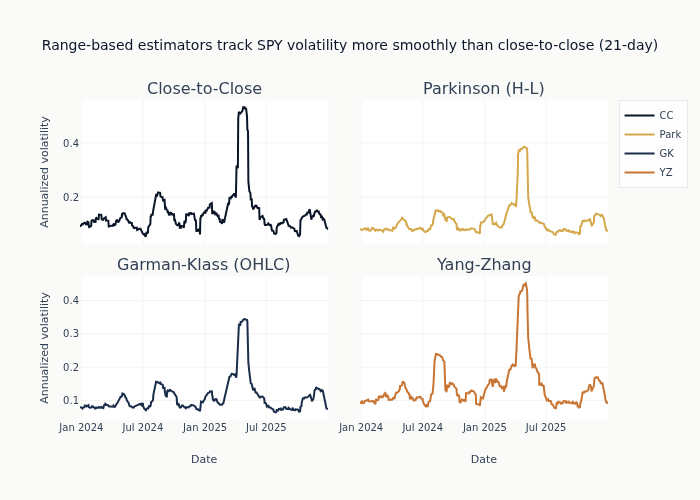

In [19]:
# 4-panel comparison
n = 504  # Last ~2 years for visualization
fig = make_subplots(
    rows=2,
    cols=2,
    shared_xaxes=True,
    shared_yaxes=True,
    subplot_titles=["Close-to-Close", "Parkinson (H-L)", "Garman-Klass (OHLC)", "Yang-Zhang"],
    vertical_spacing=0.10,
    horizontal_spacing=0.06,
)

for idx, (col, name) in enumerate(
    [("vol_cc", "CC"), ("vol_parkinson", "Park"), ("vol_gk", "GK"), ("vol_yz", "YZ")]
):
    row, c = idx // 2 + 1, idx % 2 + 1
    fig.add_trace(
        go.Scatter(
            x=vol_compare_df["timestamp"].to_list()[-n:],
            y=vol_compare_df[col].to_list()[-n:],
            name=name,
        ),
        row=row,
        col=c,
    )

fig.update_yaxes(title_text="Annualized volatility", col=1)
fig.update_xaxes(title_text="Date", row=2)
fig.update_layout(
    height=500,
    title="Range-based estimators track SPY volatility more smoothly than close-to-close (21-day)",
)
fig.show()

**Interpretation**: Range-based estimators (Parkinson, GK, YZ) are smoother
and more responsive than close-to-close. During high-volatility events
(e.g., March 2020), the range-based estimators capture intraday dynamics
that CC misses. Yang-Zhang is preferred for most applications.

### Four OHLC Estimators Overlaid

Overlaying all four estimators on a single panel makes their level and timing
differences directly comparable. Line styles vary alongside color so the series
stay distinct in grayscale.

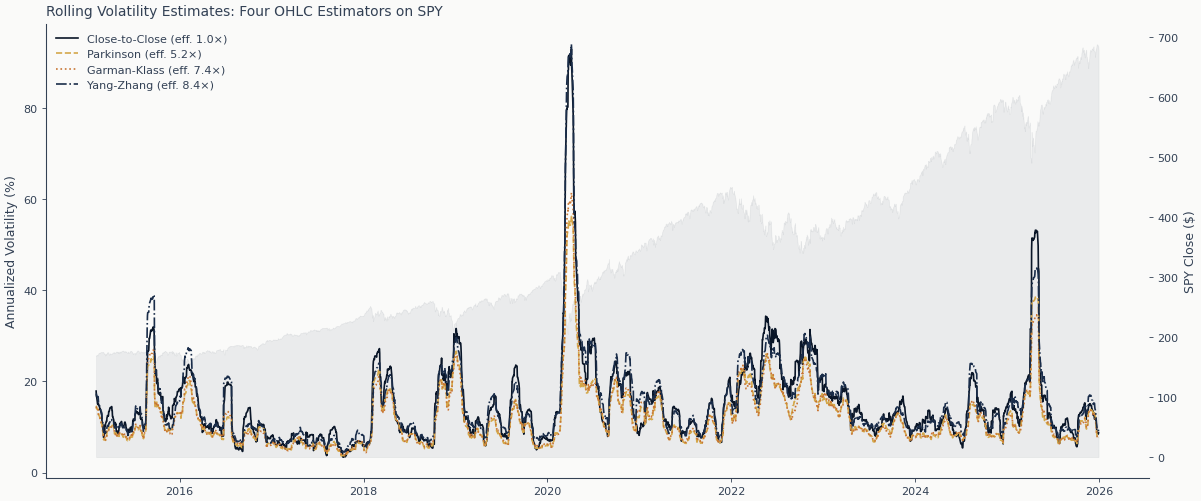

In [20]:
import matplotlib.pyplot as plt

# Prepare data — use full history for a window that includes a volatility spike
vol_plot = vol_compare_df.drop_nulls(subset=["vol_cc", "vol_parkinson", "vol_gk", "vol_yz"])

fig_mpl, ax = plt.subplots(figsize=(12, 5))

# SPY close price on secondary axis (context for vol spikes)
ax2 = ax.twinx()
dates = vol_plot["timestamp"].to_list()
ax2.fill_between(dates, vol_plot["close"].to_list(), alpha=0.08, color=COLORS["neutral"])
ax2.set_ylabel("SPY Close ($)", color=COLORS["neutral"])
ax2.tick_params(axis="y", labelcolor=COLORS["neutral"])

# Vol estimators on primary axis (convert to percentage for readability).
# Line styles vary alongside color so the four series stay distinct in grayscale print.
estimators = [
    ("vol_cc", "Close-to-Close (eff. 1.0\u00d7)", "-", COLORS["blue"]),
    ("vol_parkinson", "Parkinson (eff. 5.2\u00d7)", "--", COLORS["amber"]),
    ("vol_gk", "Garman-Klass (eff. 7.4\u00d7)", ":", COLORS["copper"]),
    ("vol_yz", "Yang-Zhang (eff. 8.4\u00d7)", "-.", COLORS["slate"]),
]

for col, label, ls, color in estimators:
    vals = [v * 100 for v in vol_plot[col].to_list()]
    ax.plot(dates, vals, ls=ls, color=color, label=label, linewidth=1.2)

ax.set_ylabel("Annualized Volatility (%)")
ax.set_title("Rolling Volatility Estimates: Four OHLC Estimators on SPY")
ax.legend(frameon=False, fontsize=8, loc="upper left")
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)

plt.show()

# Persist source data so the book figure script can re-render at print resolution
# without re-executing this notebook.
_FIG_8_3_ARTIFACT = (
    get_chapter_dir(8)
    / "output"
    / "book_figure_artifacts"
    / "figure_8_3_ohlc_volatility_estimators.parquet"
)
_FIG_8_3_ARTIFACT.parent.mkdir(parents=True, exist_ok=True)
vol_plot.select(
    ["timestamp", "close", "vol_cc", "vol_parkinson", "vol_gk", "vol_yz"]
).write_parquet(_FIG_8_3_ARTIFACT)

### 4.3 Volatility-of-Volatility (Vol-of-Vol)

Second moment of volatility — useful for detecting unstable regimes.

In [21]:
from ml4t.engineer.features.volatility import volatility_of_volatility

vov_df = spy.with_columns(
    [
        yang_zhang_volatility("open", "high", "low", "close", period=21, annualize=True).alias(
            "vol"
        ),
        volatility_of_volatility("close", vol_period=21, vov_period=21).alias("vol_of_vol"),
    ]
)

print("Vol-of-vol (last 10 rows):")
vov_df.select(["timestamp", "vol", "vol_of_vol"]).tail(10)

Vol-of-vol (last 10 rows):


timestamp,vol,vol_of_vol
date,f64,f64
2025-12-17,0.139761,0.621495
2025-12-18,0.138174,0.621355
2025-12-19,0.135311,0.627816
2025-12-22,0.113959,0.7117
2025-12-23,0.104625,0.702293
2025-12-24,0.101127,0.725698
2025-12-26,0.094439,0.730119
2025-12-29,0.094514,0.71926
2025-12-30,0.094401,0.709079


### 4.4 Volatility State Features

Volatility state features transform continuous vol into conditioning variables:

- **Vol ratio** (short/long): Detects expansion/contraction
- **Vol percentile**: Where current vol sits in its 252-day history
- **Vol decile**: Binned version for evaluation slicing

In [22]:
SHORT_VOL_WINDOW = 10
LONG_VOL_WINDOW = 63
PERCENTILE_LOOKBACK = 252

vol_state_df = (
    spy.with_columns(
        pl.col("close").log().diff().alias("log_return"),
    )
    .with_columns(
        [
            (pl.col("log_return").rolling_std(SHORT_VOL_WINDOW) * np.sqrt(252)).alias("vol_short"),
            (pl.col("log_return").rolling_std(LONG_VOL_WINDOW) * np.sqrt(252)).alias("vol_long"),
        ]
    )
    .with_columns(
        # Vol ratio: short/long — >1 means expansion, <1 contraction
        (pl.col("vol_short") / pl.col("vol_long").clip(1e-10, None)).alias("vol_ratio"),
    )
)

# Vol percentile: rolling rank over 252 days
vol_state_df = vol_state_df.with_columns(
    pl.col("vol_short")
    .rolling_map(
        lambda s: 100 * (s.rank().last() - 1) / max(len(s) - 1, 1),
        window_size=PERCENTILE_LOOKBACK,
        min_periods=PERCENTILE_LOOKBACK // 2,
    )
    .alias("vol_percentile")
)

# Vol decile: clipped 0-9
vol_state_df = vol_state_df.with_columns(
    (pl.col("vol_percentile").fill_nan(None).fill_null(-10.0) / 10)
    .floor()
    .clip(0, 9)
    .cast(pl.Int32)
    .alias("vol_decile")
)

print("Volatility state features:")
vol_state_df.select(["timestamp", "vol_ratio", "vol_percentile", "vol_decile"]).tail(10)

Volatility state features:


timestamp,vol_ratio,vol_percentile,vol_decile
date,f64,f64,i32
2025-12-17,0.70343,24.701195,2
2025-12-18,0.791156,29.482072,2
2025-12-19,0.878894,36.25498,3
2025-12-22,0.907711,39.840637,3
2025-12-23,0.919026,41.434263,4
2025-12-24,0.896418,38.645418,3
2025-12-26,0.896616,38.645418,3
2025-12-29,0.773062,27.49004,2
2025-12-30,0.77205,27.49004,2


### 4.5 Price-Derived Regime Indicators

`ml4t-engineer` provides rolling statistical tests that detect market regime
changes without relying on parametric models (HMM, GARCH are in Chapter 9):

| Indicator | Test/Signal | Interpretation |
|-----------|-------------|----------------|
| **Variance Ratio** | Lo-MacKinlay RW test | >1 trending, <1 mean-reverting |
| **Fractal Efficiency** | Mandelbrot efficiency | 1=trending, 0=noise |
| **Trend Intensity** | ADX-like directional | High=strong trend |

In [23]:
from ml4t.engineer.features.regime import fractal_efficiency, trend_intensity_index, variance_ratio

vr_exprs = variance_ratio("close", periods=[5], window=21)
regime_ind_df = spy.with_columns(
    [
        vr_exprs["vr_5"].alias("variance_ratio_21d"),
        fractal_efficiency("close", period=21).alias("fractal_eff_21d"),
        trend_intensity_index("close", period=21).alias("trend_intensity_21d"),
    ]
)

print("Regime indicators:")
regime_ind_df.select(
    ["timestamp", "variance_ratio_21d", "fractal_eff_21d", "trend_intensity_21d"]
).tail(10)

Regime indicators:


timestamp,variance_ratio_21d,fractal_eff_21d,trend_intensity_21d
date,f64,f64,f64
2025-12-17,1.574923,0.068061,53.403025
2025-12-18,1.475453,0.195888,59.794423
2025-12-19,1.209418,0.228892,61.444618
2025-12-22,1.328412,0.421647,71.082353
2025-12-23,1.27028,0.396741,69.837071
2025-12-24,1.73126,0.334747,66.737327
2025-12-26,1.913859,0.268469,63.423459
2025-12-29,1.864309,0.163613,58.180633
2025-12-30,1.375682,0.094976,54.748779


**Variance Ratio**: Values above 1 indicate positive autocorrelation (trending);
below 1 indicates mean-reversion. This is the Lo-MacKinlay (1988) test as a
rolling feature.

**Fractal Efficiency**: Measures path efficiency — 1 means price moves in a
straight line (trend), 0 means random wandering.

**Note**: These are *rolling-window* regime indicators derived purely from price.
Parametric regime models (HMM, Markov-switching GARCH) appear in Chapter 9.

## 5. Volume and Liquidity Features

Volume features proxy for:
- **Attention**: High volume = information event
- **Liquidity**: Capacity to trade
- **Conviction**: Volume confirms price moves

### 5.1 Dollar Volume

Raw volume is not comparable across assets. Dollar volume normalizes.

$$\text{Dollar Volume} = \text{Volume} \times \text{Close}$$

In [24]:
volume_df = spy.with_columns(
    [
        (pl.col("volume") * pl.col("close")).alias("dollar_volume"),
        # Log transform for better distribution
        (pl.col("volume") * pl.col("close")).log().alias("log_dollar_volume"),
    ]
)

print("Dollar volume:")
volume_df.select(["timestamp", "close", "volume", "dollar_volume"]).tail(10)

Dollar volume:


timestamp,close,volume,dollar_volume
date,f64,f64,f64
2025-12-17,667.598694,1.106252e8,7.3853e10
2025-12-18,672.639954,1.086501e8,7.3082e10
2025-12-19,678.736389,1.035995e8,7.0317e10
2025-12-22,682.964844,6.95567e7,4.7505e10
2025-12-23,686.086304,6.484e7,4.4486e10
2025-12-24,688.499695,3.94456e7,2.7158e10
2025-12-26,688.429871,4.16133e7,2.8648e10
2025-12-29,685.976562,6.25595e7,4.2914e10
2025-12-30,685.138916,4.71607e7,3.2312e10


### 5.2 Relative Volume

Volume relative to its recent average. >1 means above-average activity.

$$\text{Relative Volume} = \frac{V_t}{\text{SMA}_{21}(V)}$$

In [25]:
rel_vol_df = spy.with_columns(
    [
        (pl.col("volume") / pl.col("volume").rolling_mean(21)).alias("rel_volume"),
        # Volume shock: z-score of log volume
        (
            (pl.col("volume").log() - pl.col("volume").log().rolling_mean(21))
            / pl.col("volume").log().rolling_std(21)
        ).alias("volume_zscore"),
    ]
)

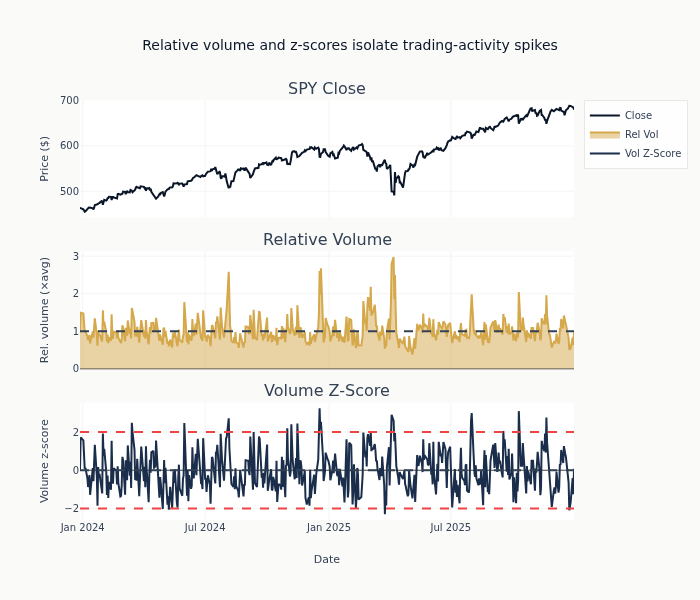

In [26]:
# Visualize relative volume features
fig = make_subplots(
    rows=3,
    cols=1,
    shared_xaxes=True,
    subplot_titles=["SPY Close", "Relative Volume", "Volume Z-Score"],
    vertical_spacing=0.08,
)

fig.add_trace(
    go.Scatter(
        x=rel_vol_df["timestamp"].to_list()[-n:], y=rel_vol_df["close"].to_list()[-n:], name="Close"
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=rel_vol_df["timestamp"].to_list()[-n:],
        y=rel_vol_df["rel_volume"].to_list()[-n:],
        name="Rel Vol",
        fill="tozeroy",
    ),
    row=2,
    col=1,
)
fig.add_hline(y=1, line_dash="dash", line_color=COLORS["neutral"], row=2, col=1)
fig.add_trace(
    go.Scatter(
        x=rel_vol_df["timestamp"].to_list()[-n:],
        y=rel_vol_df["volume_zscore"].to_list()[-n:],
        name="Vol Z-Score",
    ),
    row=3,
    col=1,
)
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], row=3, col=1)
fig.add_hline(y=2, line_dash="dash", line_color=COLORS["negative"], row=3, col=1)
fig.add_hline(y=-2, line_dash="dash", line_color=COLORS["negative"], row=3, col=1)

fig.update_yaxes(title_text="Price ($)", row=1, col=1)
fig.update_yaxes(title_text="Rel. volume (×avg)", row=2, col=1)
fig.update_yaxes(title_text="Volume z-score", row=3, col=1)
fig.update_xaxes(title_text="Date", row=3, col=1)
fig.update_layout(height=600, title="Relative volume and z-scores isolate trading-activity spikes")
fig.show()

### 5.3 VWAP Distance

How far price has moved from the volume-weighted average price.
Useful for intraday strategies and execution.

$$\text{VWAP Distance} = \frac{P_t - VWAP_t}{VWAP_t}$$

In [27]:
# Daily VWAP using typical price as proxy
vwap_df = (
    spy.with_columns(
        [
            # Typical price as VWAP proxy for daily data
            ((pl.col("high") + pl.col("low") + pl.col("close")) / 3).alias("typical_price"),
        ]
    )
    .with_columns(
        [
            # Rolling VWAP (volume-weighted rolling mean)
            (
                (pl.col("typical_price") * pl.col("volume")).rolling_sum(5)
                / pl.col("volume").rolling_sum(5)
            ).alias("vwap_5d"),
        ]
    )
    .with_columns(
        [
            ((pl.col("close") / pl.col("vwap_5d")) - 1).alias("vwap_distance"),
        ]
    )
)

print("VWAP distance:")
vwap_df.select(["timestamp", "close", "vwap_5d", "vwap_distance"]).tail(10)

VWAP distance:


timestamp,close,vwap_5d,vwap_distance
date,f64,f64,f64
2025-12-17,667.598694,676.727428,-0.01349
2025-12-18,672.639954,675.104033,-0.00365
2025-12-19,678.736389,674.66599,0.006033
2025-12-22,682.964844,675.023496,0.011765
2025-12-23,686.086304,676.558512,0.014083
2025-12-24,688.499695,679.433863,0.013343
2025-12-26,688.429871,682.629445,0.008497
2025-12-29,685.976562,685.249602,0.001061
2025-12-30,685.138916,686.255175,-0.001627


**Interpretation**: Positive VWAP distance means the close is above the
volume-weighted average — buying pressure exceeded selling pressure over the
lookback. Negative indicates the opposite. For intraday strategies this is a
key mean-reversion anchor; for daily data it proxies volume-weighted trend.

## 6. Cross-Sectional Normalization

For multi-asset strategies, raw features are not comparable. Normalization
creates standardized signals across the universe.

**Warning**: Cross-sectional operations can introduce leakage if not careful
about timing. Always use point-in-time data.

### 6.1 Cross-Sectional Ranks

Rank-based features are robust to outliers.

$$\text{Rank}_{t,i} = \frac{\text{rank}(f_{t,i})}{\text{N}_t}$$

In [28]:
# Add momentum to cross-sectional data
cs_mom = cs_etfs.with_columns(
    [
        pl.col("close").pct_change(21).over("symbol").alias("mom_21d"),
    ]
)

# Cross-sectional rank within each day
cs_ranked = cs_mom.with_columns(
    [
        # Rank: 0 = lowest momentum, 1 = highest
        (
            pl.col("mom_21d").rank().over("timestamp") / pl.col("symbol").count().over("timestamp")
        ).alias("mom_rank"),
    ]
)

# Show one day
sample_date = cs_ranked["timestamp"].max()
print(f"Cross-sectional ranks for {sample_date}:")
(
    cs_ranked.filter(pl.col("timestamp") == sample_date)
    .select(["symbol", "mom_21d", "mom_rank"])
    .sort("mom_rank", descending=True)
)

Cross-sectional ranks for 2025-12-31:


symbol,mom_21d,mom_rank
str,f64,f64
"""XLF""",0.039165,1.0
"""GLD""",0.016831,0.875
"""XLK""",0.007078,0.75
"""IWM""",0.005559,0.625
"""SPY""",0.005388,0.5
"""QQQ""",-0.003352,0.375
"""XLE""",-0.012459,0.25
"""TLT""",-0.014316,0.125


### 6.2 Vol-Scaled Cross-Sectional Momentum

The text's spec-table formula: cumulative return divided by realized volatility,
then cross-sectional percentile rank. Vol-scaling penalizes momentum driven by
high volatility — a stock that rose 10% with 40% vol is less compelling than one
that rose 10% with 15% vol.

$$\text{Vol-Scaled Mom} = \frac{r_{21d}}{\sigma_{21d}}$$

In [29]:
# Vol-scaled momentum: return / realized vol
cs_vol_scaled = cs_etfs.with_columns(
    [
        pl.col("close").pct_change(21).over("symbol").alias("mom_21d"),
        (
            pl.col("close").pct_change().over("symbol").rolling_std(21).over("symbol")
            * np.sqrt(252)
        ).alias("vol_21d"),
    ]
).with_columns(
    (pl.col("mom_21d") / pl.col("vol_21d").clip(1e-10, None)).alias("vol_scaled_mom"),
)

# Cross-sectional percentile rank
cs_vol_ranked = cs_vol_scaled.with_columns(
    (
        pl.col("vol_scaled_mom").rank().over("timestamp")
        / pl.col("symbol").count().over("timestamp")
    ).alias("vol_scaled_rank"),
)

# Compare raw vs vol-scaled rankings
print(f"Vol-scaled cross-sectional momentum ({sample_date}):")
(
    cs_vol_ranked.filter(pl.col("timestamp") == sample_date)
    .select(["symbol", "mom_21d", "vol_21d", "vol_scaled_mom", "vol_scaled_rank"])
    .sort("vol_scaled_rank", descending=True)
)

Vol-scaled cross-sectional momentum (2025-12-31):


symbol,mom_21d,vol_21d,vol_scaled_mom,vol_scaled_rank
str,f64,f64,f64,f64
"""XLF""",0.039165,0.109871,0.356463,1.0
"""GLD""",0.016831,0.197855,0.085069,0.875
"""SPY""",0.005388,0.087235,0.06176,0.75
"""XLK""",0.007078,0.181343,0.03903,0.625
"""IWM""",0.005559,0.143184,0.038827,0.5
"""QQQ""",-0.003352,0.132129,-0.025366,0.375
"""XLE""",-0.012459,0.193407,-0.064418,0.25
"""TLT""",-0.014316,0.068914,-0.207732,0.125


**Interpretation**: Vol-scaling reshuffles the ranking — high-momentum assets
with elevated volatility drop, while steady trending assets rise. This is the
same intuition as the Sharpe ratio applied cross-sectionally.

### 6.3 Cross-Sectional Z-Scores

Z-score normalization assumes (roughly) normal distribution.

$$z_{t,i} = \frac{f_{t,i} - \mu_t}{\sigma_t}$$

**Robustness**: Use median/MAD instead of mean/std for robustness to outliers.

In [30]:
# Z-score within each day
cs_zscored = cs_mom.with_columns(
    [
        # Standard z-score
        (
            (pl.col("mom_21d") - pl.col("mom_21d").mean().over("timestamp"))
            / pl.col("mom_21d").std().over("timestamp")
        ).alias("mom_zscore"),
        # Robust z-score (using median and MAD)
        # MAD × 1.4826 ≈ σ for normal data (1.4826 = 1/Φ⁻¹(3/4))
        (
            (pl.col("mom_21d") - pl.col("mom_21d").median().over("timestamp"))
            / (
                (pl.col("mom_21d") - pl.col("mom_21d").median().over("timestamp"))
                .abs()
                .median()
                .over("timestamp")
                * 1.4826
            )
        ).alias("mom_zscore_robust"),
    ]
)

# Show one day
print(f"Cross-sectional z-scores for {sample_date}:")
(
    cs_zscored.filter(pl.col("timestamp") == sample_date)
    .select(["symbol", "mom_21d", "mom_zscore", "mom_zscore_robust"])
    .sort("mom_zscore", descending=True)
)

Cross-sectional z-scores for 2025-12-31:


symbol,mom_21d,mom_zscore,mom_zscore_robust
str,f64,f64,f64
"""XLF""",0.039165,1.964256,2.251856
"""GLD""",0.016831,0.661662,0.759133
"""XLK""",0.007078,0.092793,0.10723
"""IWM""",0.005559,0.004228,0.005739
"""SPY""",0.005388,-0.005787,-0.005739
"""QQQ""",-0.003352,-0.515499,-0.589849
"""XLE""",-0.012459,-1.046683,-1.198566
"""TLT""",-0.014316,-1.15497,-1.322659


### 6.4 Leakage Warning: Point-in-Time Discipline

**Common Leakage Patterns**:

1. **Using future data**: Z-score computed over future values
2. **Survivorship bias**: Only including current constituents
3. **Look-ahead in ranks**: Ranking before data was available

**Safe Pattern**: Always use `.over("timestamp")` for cross-sectional
operations — this guarantees that each date's statistics use only
contemporaneous data:

```python
# WRONG: full-sample z-score includes future data
pl.col("mom").zscore()

# CORRECT: point-in-time cross-sectional z-score
(pl.col("mom") - pl.col("mom").mean().over("timestamp"))
/ pl.col("mom").std().over("timestamp")
```

## 7. Risk Features

Risk features capture the *shape* of the return distribution beyond simple volatility.
Tail risk measures like VaR, CVaR, and tail ratio are essential for:
- **Position sizing**: Scale down exposure when tail risk is elevated
- **Feature conditioning**: Momentum works differently in fat-tail vs thin-tail regimes
- **Risk-adjusted signals**: Sharpe ratios penalize return/vol; CVaR penalizes tail events

In [31]:
from ml4t.engineer.features.risk import (
    conditional_value_at_risk,
    downside_deviation,
    tail_ratio,
    value_at_risk,
)

risk_df = spy.with_columns(
    [
        pl.col("close").pct_change().alias("ret"),
    ]
).with_columns(
    [
        value_at_risk("ret", confidence_level=0.95, window=63).alias("var_5pct_63d"),
        conditional_value_at_risk("ret", confidence_level=0.95, window=63).alias("cvar_5pct_63d"),
        downside_deviation("ret", window=63).alias("downside_dev_63d"),
        tail_ratio("ret", confidence_level=0.95, window=63).alias("tail_ratio_63d"),
    ]
)

print("Risk features (last 10 rows):")
risk_df.select(
    ["timestamp", "var_5pct_63d", "cvar_5pct_63d", "downside_dev_63d", "tail_ratio_63d"]
).tail(10)

Risk features (last 10 rows):


timestamp,var_5pct_63d,cvar_5pct_63d,downside_dev_63d,tail_ratio_63d
date,f64,f64,f64,f64
2025-12-17,-0.011854,-0.017679,0.005919,0.99529
2025-12-18,-0.011854,-0.017679,0.005919,0.99529
2025-12-19,-0.011854,-0.017679,0.005919,0.99529
2025-12-22,-0.011854,-0.017679,0.005879,0.99529
2025-12-23,-0.011854,-0.017679,0.005866,0.99529
2025-12-24,-0.011854,-0.017679,0.005837,0.99529
2025-12-26,-0.011854,-0.017679,0.005837,0.99529
2025-12-29,-0.011854,-0.017679,0.005854,0.99529
2025-12-30,-0.011854,-0.017679,0.005856,0.99529


| Risk Feature | Interpretation | Trading Use |
|-------------|----------------|-------------|
| **VaR (5% tail)** | Max expected loss in worst 5% of days | Position sizing threshold |
| **CVaR (5%)** | Expected loss beyond VaR | Tail risk penalty |
| **Downside Deviation** | Volatility of negative returns only | Sortino ratio denominator |
| **Tail Ratio** | Right tail / left tail size | Asymmetry of return distribution |

## 8. ML-Specific Transforms

ML-specific transforms prepare features for tree and linear models:
- **Fractional differencing**: Makes features stationary while preserving memory
- **Volatility-adjusted returns**: Standardizes by recent volatility

In [32]:
from ml4t.engineer.features.fdiff import ffdiff

# Fractional differencing preserves memory while achieving stationarity
# d=0.5 is a common starting point; use find_optimal_d() for data-driven choice
ffd_df = spy.with_columns(
    [
        ffdiff("close", d=0.5).alias("close_ffd_05"),
        ffdiff("close", d=1.0).alias("close_ffd_10"),  # Equivalent to first difference
    ]
)

print("Fractional differencing (d=0.5 vs d=1.0):")
ffd_df.select(["timestamp", "close", "close_ffd_05", "close_ffd_10"]).tail(10)

Fractional differencing (d=0.5 vs d=1.0):


timestamp,close,close_ffd_05,close_ffd_10
date,f64,f64,f64
2025-12-17,667.598694,9.985787,-7.427734
2025-12-18,672.639954,19.091705,5.04126
2025-12-19,678.736389,23.756835,6.096436
2025-12-22,682.964844,24.851874,4.228455
2025-12-23,686.086304,25.111019,3.12146
2025-12-24,688.499695,25.074662,2.413391
2025-12-26,688.429871,22.919109,-0.069824
2025-12-29,685.976562,19.677513,-2.453308
2025-12-30,685.138916,19.56021,-0.837646


| Transform | d Value | Stationarity | Memory | Use Case |
|-----------|---------|-------------|--------|----------|
| Original | 0.0 | Non-stationary | Full | Not for ML |
| Fractional | 0.3-0.5 | Near-stationary | Preserved | Tree models, regressions |
| First diff | 1.0 | Stationary | Lost | Benchmark comparison |

Fractional differencing with $d \approx 0.5$ is a good default for financial
time series. It achieves stationarity (required by most ML models) while
retaining long-range dependence that purely differenced series lose.

**Caveat**: With finite truncation, `d=1.0` *approximates* but does not
exactly equal first differencing. The truncated weight series drops small
high-lag coefficients that a true first difference implicitly includes. For
practical purposes the difference is negligible, but be aware when comparing
FFD output to `pct_change()`.

**ml4t-engineer Production API**: For production feature computation using
config-driven batch processing and library RSI/MACD/Bollinger implementations,
see `10_ml4t_library_ecosystem` (Chapter 7).

## Summary

### Feature Family Decision Guide

| Family | When to Use | Key Considerations |
|--------|-------------|-------------------|
| **Returns** | Base signals, momentum | Skip-1 for short horizons |
| **Trend** | Trend-following | Vol-scale for comparability |
| **Volatility** | Risk scaling, sizing | Yang-Zhang most efficient |
| **Vol State** | Regime conditioning | Percentile > decile for granularity |
| **Regime Indicators** | Trend detection | Rolling-window, model-free |
| **Volume** | Liquidity, conviction | Use relative, not raw |
| **Risk** | Position sizing, tail risk | VaR, CVaR, downside dev |
| **Cross-sectional** | Multi-asset | Point-in-time discipline |
| **ML transforms** | Stationarity | Fractional differencing |

### Implementation Rules

1. **Sort once at load**: `df.sort(["symbol", "timestamp"])`
2. **Single with_columns**: All transforms in one call for parallelism
3. **Vol-scale for comparability**: Raw features vary with price level
4. **Library for production**: ml4t-engineer for validated implementations
5. **Point-in-time for cross-sectional**: Use `.over("timestamp")`

### Next Notebooks

- `02_microstructure_features` — Trade-based features (§8.2)
- `03_structural_cross_instrument_features` — Carry, cross-asset, options (§8.3)
- `04_fundamentals_macro_calendar` — Fundamentals, macro, calendar (§8.4)